In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [11]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [12]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [14]:
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.duplicated().sum())

723
0


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [15]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(241, 13)
(61, 13)
(241,)
(61,)


In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
X_train_df = pd.DataFrame(X_train,columns = X.columns)
X_train_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.682633,0.685210,-0.980054,-0.403153,0.486281,-0.425879,-1.024877,0.717007,-0.718139,-0.447524,-0.715539,-0.705536,1.118119
1,0.403989,0.685210,-0.980054,-0.171406,0.206315,-0.425879,-1.024877,-0.836627,1.392489,1.768032,-0.715539,1.248879,1.118119
2,-1.008619,-1.459407,-0.004050,-0.055533,-0.260295,-0.425879,-1.024877,1.105415,-0.718139,-0.358902,-0.715539,-0.705536,-0.545256
3,-1.117282,0.685210,-0.004050,-0.634899,-0.521596,-0.425879,0.860584,0.889633,-0.718139,-0.890635,0.991836,-0.705536,-0.545256
4,0.838637,-1.459407,-0.980054,1.103201,-0.073651,-0.425879,0.860584,0.199129,1.392489,0.350076,-0.715539,-0.705536,-0.545256
...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,1.381948,0.685210,-0.980054,-0.634899,-0.204301,-0.425879,0.860584,-3.382861,-0.718139,-0.004413,-0.715539,-0.705536,-0.545256
237,0.947300,0.685210,-0.980054,0.523834,-1.137521,-0.425879,-1.024877,-0.232436,1.392489,2.654254,0.991836,1.248879,1.118119
238,0.621313,-1.459407,1.947959,1.103201,-0.148308,-0.425879,0.860584,0.932789,-0.718139,-0.093035,0.991836,-0.705536,-0.545256
239,1.381948,-1.459407,0.971955,1.219074,0.542274,-0.425879,0.860584,0.975946,-0.718139,-0.890635,0.991836,0.271672,-0.545256


In [26]:
y_pred = rf_model.predict(X_test)
cfmt = confusion_matrix(y_test, y_pred)
f1_score_rf = f1_score(y_test, y_pred)
recall_rf = recall_score(y_test, y_pred)
precision_rf = precision_score(y_test, y_pred)
print("Confusion Matrix:")
print(cfmt)
print("F1 Score:", f1_score_rf)
print("Recall:", recall_rf)
print("Precision:", precision_rf)

Confusion Matrix:
[[25  7]
 [ 3 26]]
F1 Score: 0.8387096774193549
Recall: 0.896551724137931
Precision: 0.7878787878787878


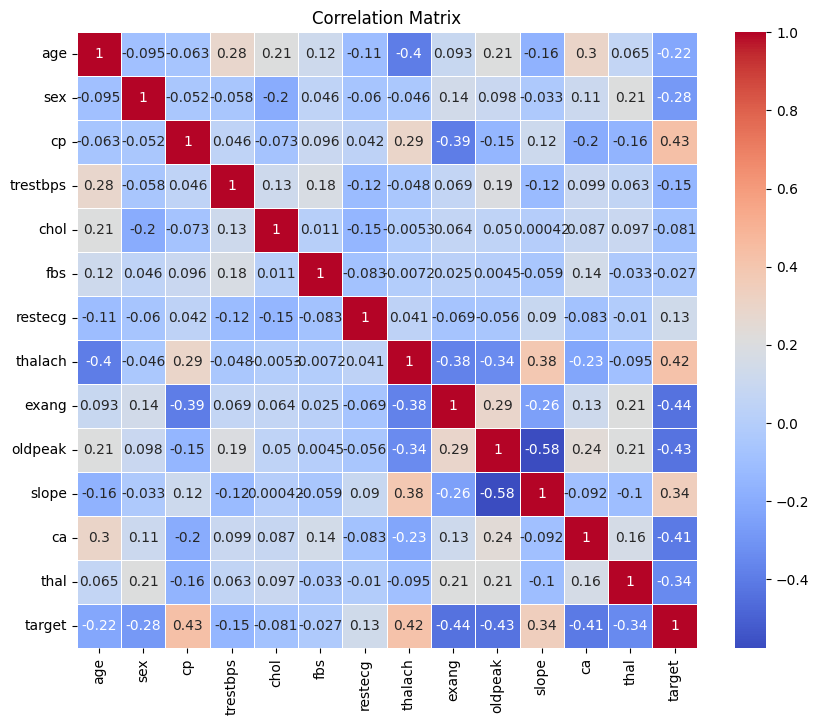

In [29]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()